# Bayesian Parameter Estimation

In this notebook, we will estimate a single parameter: the true value of a physical quantity, $\mu$ (for example, a particle mass, so $\mu > 0$).

Assume we have a detector with a known measurement resolution (standard deviation) of $\sigma = 1.5$. We take 5 independent measurements of this quantity.

We will use numerical integration over a 1D array to calculate the Posterior PDF using Bayes' Theorem:
$$P(\mu|Data) = \frac{P(Data|\mu) \pi(\mu)}{\int P(Data|\mu) \pi(\mu) d\mu}$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy import integrate

In [3]:
# Generating the Dataset
np.random.seed(42)
true_mu = 10.0
detector_sigma = 1.5
N_measurements = 5

# Generate 5 mock measurements
data = np.random.normal(loc=true_mu, scale=detector_sigma, size=N_measurements)

print(f"Recorded measurements: {np.round(data, 2)}")
print(f"Sample mean (Frequentist estimate): {np.mean(data):.2f}")

Recorded measurements: [10.75  9.79 10.97 12.28  9.65]
Sample mean (Frequentist estimate): 10.69


## Define the Parameter Space and Likelihood

We create a 1D array of possible values for $\mu$.
The Likelihood of observing our independent data points given a specific $\mu$ is the product of their individual probabilities:
$$P(Data|\mu) = \prod_{i=1}^N \mathcal{N}(x_i | \mu, \sigma)$$

In [4]:
# Create a 1D array of possible values for the parameter mu
# We start slightly above 0 to avoid division-by-zero issues later
mu_vals = np.linspace(0.1, 20, 1000)

# Calculate the Likelihood for each value in the array
likelihood = np.ones_like(mu_vals)

for x in data:
    likelihood *= stats.norm.pdf(x, loc=mu_vals, scale=detector_sigma)

# Normalize the likelihood purely so we can plot it on the same scale as the PDFs
# (Note: The likelihood function is technically not a probability density over mu)
likelihood_plot = likelihood / integrate.simpson(likelihood, mu_vals)

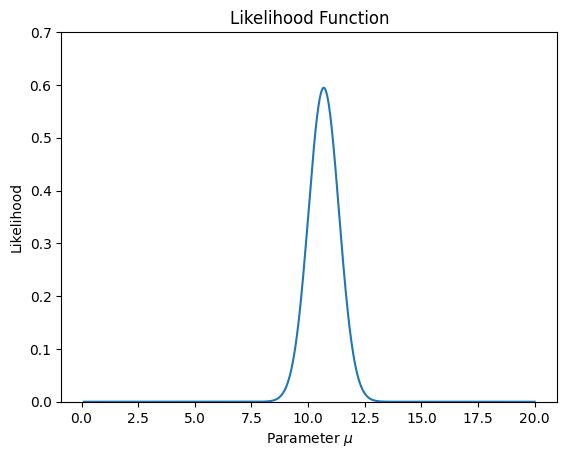

In [5]:
plt.plot(mu_vals, likelihood_plot)
plt.title("Likelihood Function")
plt.xlabel(r"Parameter $\mu$")
plt.ylabel("Likelihood")
plt.ylim(0, 0.7)
plt.show()
#@title { vertical-output: true}

## Comparing "Uninformative" Priors

If we know nothing about $\mu$ before the experiment, how do we write that mathematically? There is no single answer. Let's compare three common "uninformative" or "weakly informative" priors:

1. **Flat Prior:** $\pi(\mu) \propto 1$ (Assumes all values are equally likely).
2. **Scale-Invariant Prior:** $\pi(\mu) \propto 1/\mu$ (Assumes all orders of magnitude are equally likely; often used for strictly positive scales).
3. **Broad Gaussian:** $\mathcal{N}(0, 10)$ (A common computational choice that assigns low, but non-zero, probability to very large numbers).

In [6]:
# Define the three priors
prior_flat = np.ones_like(mu_vals)
prior_scale = 1.0 / mu_vals
prior_broad = stats.norm.pdf(mu_vals, loc=0, scale=10.0)

# Normalize them over the range of our array for simplicity
# Note that this normalisation is not needed to calculate the posterior
prior_flat /= integrate.simpson(prior_flat, mu_vals)
prior_scale /= integrate.simpson(prior_scale, mu_vals)
prior_broad /= integrate.simpson(prior_broad, mu_vals)

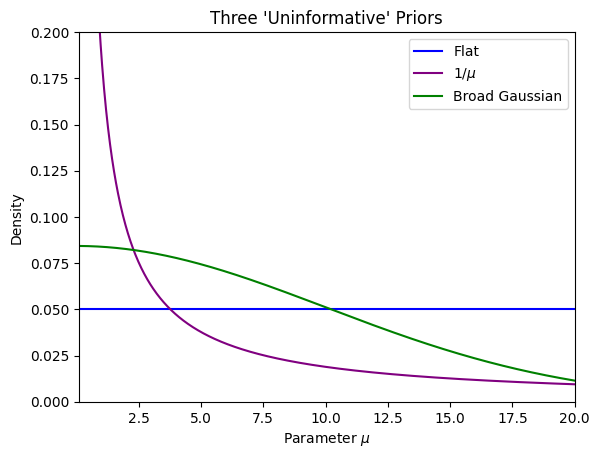

In [7]:
# Plot Priors
plt.plot(mu_vals, prior_flat, label='Flat', color='blue')
plt.plot(mu_vals, prior_scale, label=r'$1 / \mu$', color='purple')
plt.plot(mu_vals, prior_broad, label='Broad Gaussian', color='green')
plt.title("Three 'Uninformative' Priors")
plt.xlabel(r"Parameter $\mu$")
plt.ylabel("Density")
plt.ylim(0, 0.2)
plt.xlim(0.1, 20)
plt.legend()
plt.show()
#@title { vertical-output: true}

In [8]:
# Calculate Posteriors (Prior * Likelihood, then normalize)
post_flat = (prior_flat * likelihood) / integrate.simpson(prior_flat * likelihood, mu_vals)
post_scale = (prior_scale * likelihood) / integrate.simpson(prior_scale * likelihood, mu_vals)
post_broad = (prior_broad * likelihood) / integrate.simpson(prior_broad * likelihood, mu_vals)

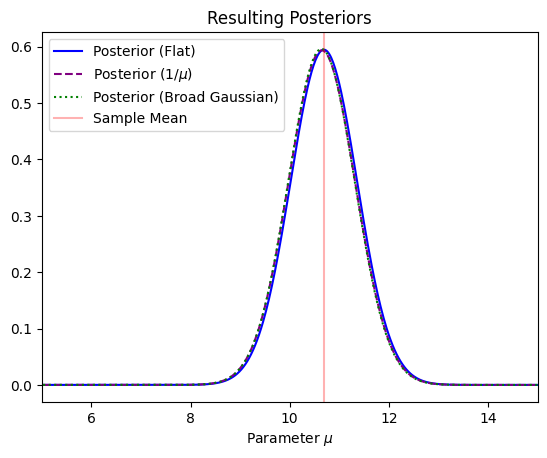

In [9]:
# Plot Posteriors
plt.plot(mu_vals, post_flat, label='Posterior (Flat)', color='blue')
plt.plot(mu_vals, post_scale, label=r'Posterior ($1 / \mu$)', color='purple', linestyle='--')
plt.plot(mu_vals, post_broad, label='Posterior (Broad Gaussian)', color='green', linestyle=':')
plt.axvline(np.mean(data), color='red', alpha=0.3, label='Sample Mean')
plt.title("Resulting Posteriors")
plt.xlabel(r"Parameter $\mu$")
plt.xlim(5, 15) # Zoom in on the interesting region
plt.legend()
plt.show()
#@title { vertical-output: true}

## The Effect of an Informative Prior

Now, what if a previous, less precise experiment suggested that $\mu = 7.0 \pm 2.0$?
We encode this strong prior knowledge as a Gaussian distribution.

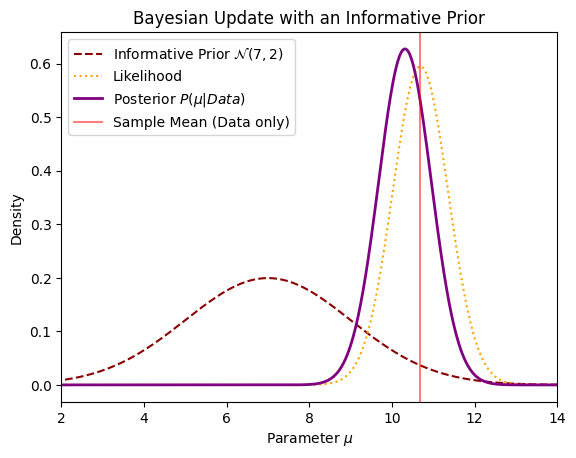

In [10]:
# Define Informative Prior (Gaussian: mean=7.0, std=2.0)
prior_info = stats.norm.pdf(mu_vals, loc=7.0, scale=2.0)

# Calculate Posterior
unnormalized_posterior_info = likelihood * prior_info
posterior_info = unnormalized_posterior_info / integrate.simpson(unnormalized_posterior_info, mu_vals)

# --- PLOTTING ---
plt.figure()
plt.plot(mu_vals, prior_info, label=r'Informative Prior $\mathcal{N}(7, 2)$', color='darkred', linestyle='--')
plt.plot(mu_vals, likelihood_plot, label=r'Likelihood', color='orange', linestyle=':')
plt.plot(mu_vals, posterior_info, label=r'Posterior $P(\mu|Data)$', color='purple', linewidth=2)

plt.axvline(np.mean(data), color='red', alpha=0.5, label='Sample Mean (Data only)')
plt.title(r"Bayesian Update with an Informative Prior")
plt.xlabel(r"Parameter $\mu$")
plt.ylabel("Density")
plt.xlim(2, 14)
plt.legend()
plt.show()
#@title { vertical-output: true}